# Function 2
This function has 2 dimensions.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF



### Data preparation

Here we prepare the initial data provided

In [2]:
input = np.load('./../../../data/initial_data/function_2/initial_inputs.npy')
output = np.load('./../../../data/initial_data/function_2/initial_outputs.npy')
print(input)
print(output)
#print(input.shape)
#print(input.shape[1])
func_dimensions = input.shape[1]
print('this function has ', func_dimensions, ' dimensions')

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]
this function has  2  dimensions


Here we add the data provided with the weekly queries

In [3]:
additionalInput = np.load('./../parsed/function2inputs.npy')
additionalOutput = np.load('./../parsed/function2outputs.npy')
print(additionalInput)
print(additionalOutput)


[[0.5  0.5 ]
 [0.36 0.5 ]
 [0.62 0.42]]
[ 0.75870817 -0.0392612   0.40007323]


In [4]:
input = np.append(input, additionalInput, axis=0)
output = np.append(output, additionalOutput)

print(input)
print(output)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.5        0.5       ]
 [0.36       0.5       ]
 [0.62       0.42      ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.75870817 -0.0392612
  0.40007323]


# Data exploration
Here we plot the available datapoints for functions with 2 dimensions

TODO: include the values in the scatterplot

[np.float64(0.6657995800131589), np.float64(0.8777909889953304), np.float64(0.14269907423594608), np.float64(0.8452754286767249), np.float64(0.45464714105124415), np.float64(0.5777128444074784), np.float64(0.4381660616117107), np.float64(0.34174959302885033), np.float64(0.33864815688701766), np.float64(0.7026365569244406), np.float64(0.5), np.float64(0.36), np.float64(0.62)]
[np.float64(0.12396912767534907), np.float64(0.7786275008473289), np.float64(0.34900513057320015), np.float64(0.7111202665952655), np.float64(0.2904551797740609), np.float64(0.7719731841154063), np.float64(0.6850182567997548), np.float64(0.028697719822277867), np.float64(0.21386724563864368), np.float64(0.9265641975455574), np.float64(0.5), np.float64(0.5), np.float64(0.42)]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.75870817 -0.0392612
  0.40007323]


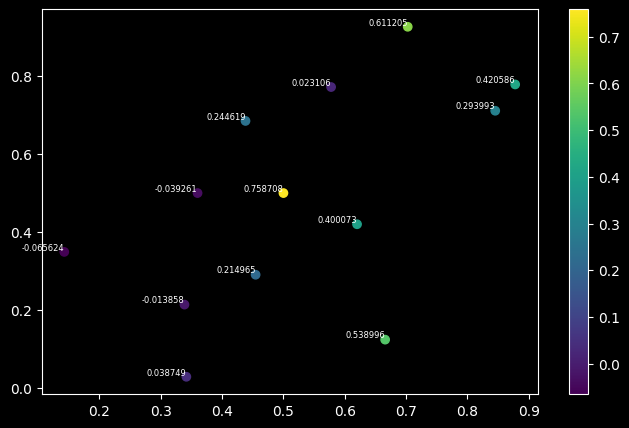

In [5]:
x = []
y = []
for i in input:
  x.append(i[0])
  y.append(i[1])

print(x)
print(y)
print(output)

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)

# Scatter plot
scatter = ax.scatter(x,y, c=output)

# Adding a color bar
plt.colorbar(scatter)

# Looping over the data points to add labels with 16 digits of precision
for i in range(len(x)):
#    x_coord = f"{X[i, 0]:.6f}"
#    y_coord = f"{X[i, 1]:.6f}"
    y_value = f"{output[i]:.6f}"
    label = f"{y_value}"
    ax.text(x[i], y[i], label, fontsize=6, ha='right', va='bottom')

plt.show()

# Bayesian Optimisation approach
We approach the study of this function with the Bayesian Optimisation
using and adaptation of the UCB acquisition function from required assignment 12.1

# Preparation of the exploration space
Here we prepare the exploration space of the function<br>
The values are increments of 0.01 bounded between 0 and 1 (included) => 101 values for each dimension of the space<br>
dimension of the current function is stored in <b>func_dimensions</b>

In [12]:
#Initialise query lists and maximum observations
X, Y = input, output

#Initialise grid for plots
vector_values = np.linspace(0, 1, 101)# 101 values from 0 to 1

# Generalised version for any number of dimension
grids = np.meshgrid(*([vector_values] * func_dimensions), indexing='ij')
x_grid = np.column_stack([grid.ravel() for grid in grids])

print(x_grid)
print(x_grid.shape)


[[0.   0.  ]
 [0.   0.01]
 [0.   0.02]
 ...
 [1.   0.98]
 [1.   0.99]
 [1.   1.  ]]
(10201, 2)


# Bayesian Optimisation with UCB applied

In [7]:
rbf_lengthscale = [0.1, 0.1]
real_noise_std = 1e-10
noise_assumption = 1e-10

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

model = GaussianProcessRegressor(kernel = kernel)
#Fit the model
model.fit(np.array(X), np.array(Y).reshape(-1, 1))


#Calculate the mean and standard deviation and make them one-dimensional for plotting
post_mean, post_std = model.predict(x_grid, return_std=True)

#Acquisition function parameter
beta = 1.96
#beta = 0.5

acquisition_function = post_mean + beta * post_std

grid = x_grid.squeeze()
obs = grid[np.argmax(acquisition_function)] #Else use the acquisition function

print('Next observation: ', obs)
#print (obs)


Next observation:  [0.61 0.58]


# Plottings

In [8]:
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
print(post_mean)
print(len(post_mean))
print(post_std)
print(len(post_std))


[6.83181931e-05 4.83395074e-05 1.98055085e-05 ... 3.08492752e-02
 2.59202269e-02 2.16440805e-02]
10201
[0.99999574 0.99999523 0.99999449 ... 0.9962686  0.99749434 0.99834986]
10201


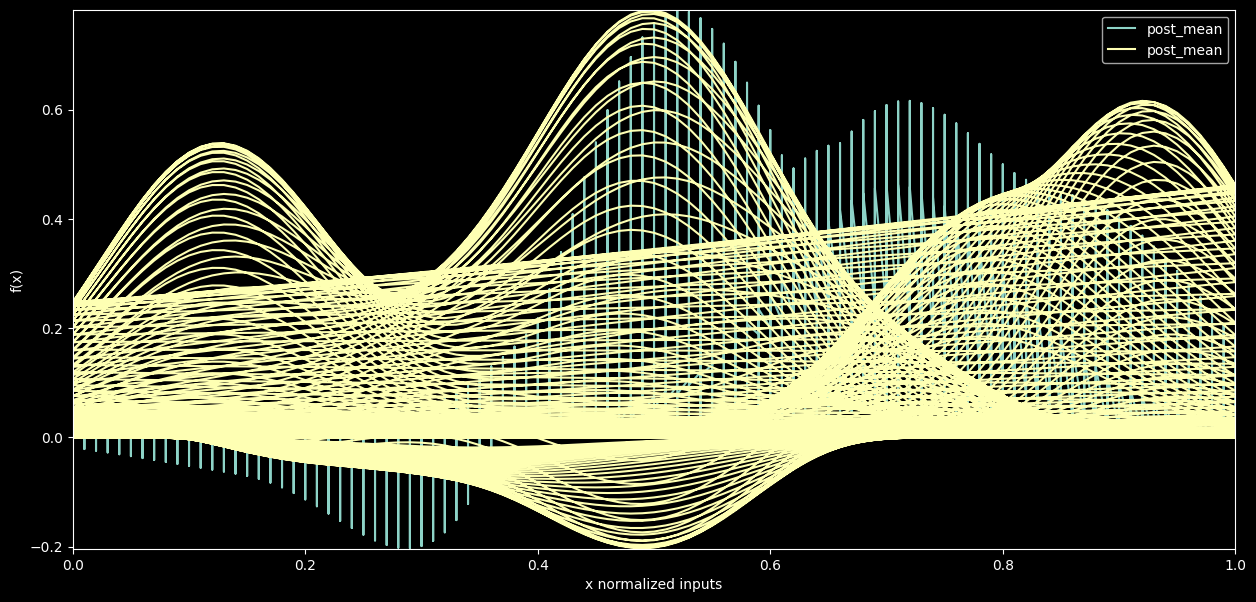

In [9]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(0, 1)
ax.set_ylim(min(post_mean) - 0.001, max(post_mean) + 0.001)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
ax.plot(x_grid, post_mean,  label = 'post_mean')
#ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



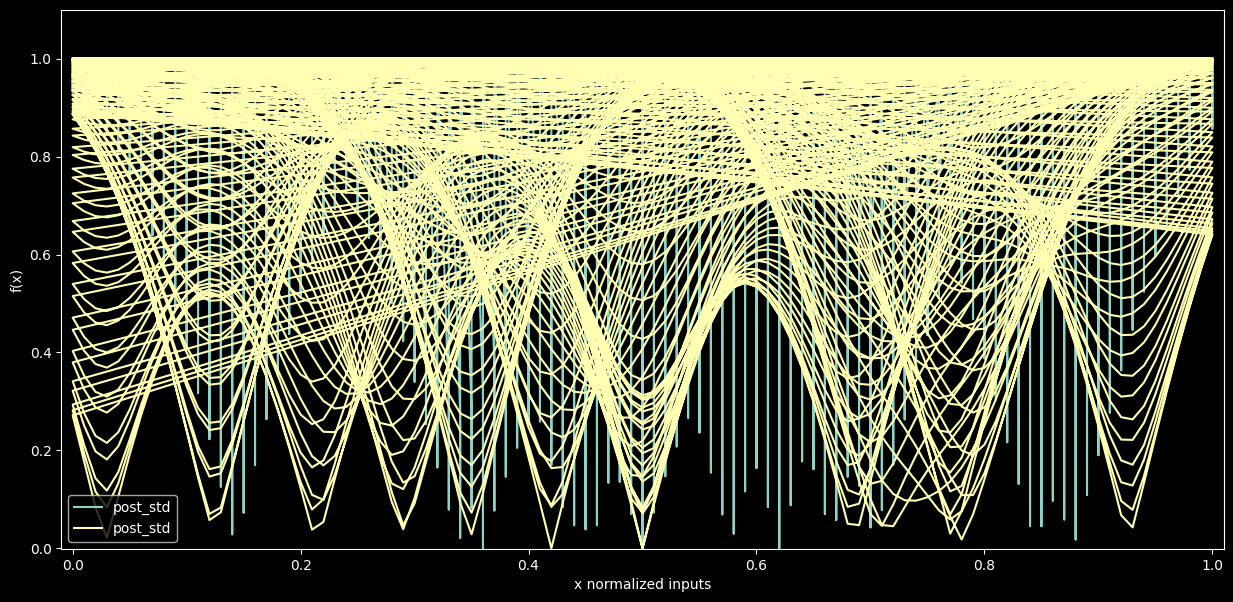

In [10]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_std) - 0.001, max(post_std) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



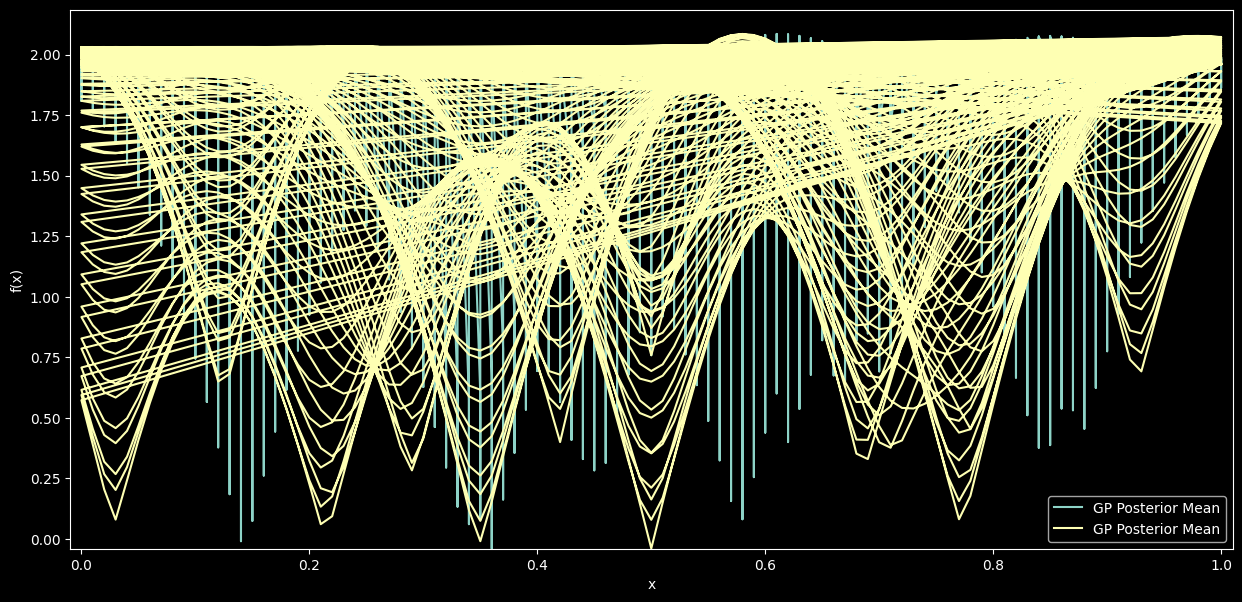

In [11]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(acquisition_function) - 0.001, max(acquisition_function) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, acquisition_function,  label = 'GP Posterior Mean')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()

